# Evaluate with a classfication

## Classification Real Data

In [2]:
random_state=99999

In [1]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from matplotlib import pyplot as plt

In [4]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from sklearn.preprocessing import OneHotEncoder

from xgboost.sklearn import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline

from sklearn.metrics import roc_auc_score,accuracy_score,f1_score,balanced_accuracy_score, precision_score, recall_score
from math import sqrt
from sklearn.metrics import classification_report

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,PrecisionRecallDisplay,RocCurveDisplay,make_scorer
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import HalvingGridSearchCV


In [5]:
%run ../../../util/functions.py

In [6]:



df_referrals_synth_orig = pd.read_csv("../../../data/synthetic/referrals_synthetic_processed.csv",sep='\t'
                           ,parse_dates=['referralStartDate']
  ,dtype=
                 
                 {
   
 'referralID': 'int',
 'patientNr'  : 'int'                 
  
                 }
                                    
                                   )


df_referrals_synth_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21950 entries, 0 to 21949
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          21950 non-null  int64         
 1   referralStartDate   21950 non-null  datetime64[ns]
 2   referralLength      21950 non-null  int64         
 3   age                 21950 non-null  int64         
 4   sex                 21950 non-null  int64         
 5   ageGrpDesc          21950 non-null  object        
 6   ageGrp              21950 non-null  int64         
 7   sexDesc             21950 non-null  object        
 8   stayLength          21950 non-null  float64       
 9   cond1axis1GrpFirst  21950 non-null  object        
 10  cond1axis1GrpLast   21950 non-null  object        
 11  numOfStays          21950 non-null  int64         
 12  factor              21950 non-null  float64       
 13  intensity           21950 non-null  float64   

In [7]:



df_referrals_real_orig = pd.read_csv("../../../data/processed/referrals_real_processed.csv",sep='\t'
                           ,parse_dates=['referralStartDate']
  ,dtype=
                 
                 {
   
 'referralID': 'int',
 'patientNr'  : 'int'                 
  
                 }
                                    
                                   )


df_referrals_real_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4895 entries, 0 to 4894
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   referralID          4895 non-null   int64         
 1   patientNr           4895 non-null   int64         
 2   age                 4895 non-null   int64         
 3   sex                 4895 non-null   int64         
 4   referralStartDate   4895 non-null   datetime64[ns]
 5   referralEndDate     4895 non-null   object        
 6   referralLength      4895 non-null   int64         
 7   numOfStays          4895 non-null   int64         
 8   cond1axis1GrpLast   4895 non-null   object        
 9   cond1axis1GrpFirst  4895 non-null   object        
 10  sexDesc             4895 non-null   object        
 11  ageGrpDesc          4895 non-null   object        
 12  ageGrp              4895 non-null   int64         
 13  factor              4895 non-null   float64     

In [8]:
multi_roc = make_scorer(roc_auc_score, average='weighted', multi_class='ovr', needs_proba=True)

In [9]:
def model_train(model,X_train, X_test, y_train, y_test,param):
    
   
   


   # stratified_kfold = StratifiedKFold(n_splits=3,
                                      # shuffle=True,
                                       #random_state=11)


    param_grid = param
    grid_search = HalvingGridSearchCV(estimator=model,
                               param_grid=param_grid,
                               scoring='roc_auc',
                               cv=3,
                               n_jobs=-1)


    grid_search.fit(X_train, y_train)
    cv_score =  grid_search.best_score_
    test_score =  grid_search.score(X_test, y_test)
    return {'clf':grid_search,'model':type(model).__name__,'cv_score':cv_score, 'test_score':test_score}

In [10]:
features =['intensityGrp'
        
        'cond1axis1GrpFirst', 'sexDesc', 'age'
       ]

In [11]:
categorical_features =[
  
      'cond1axis1GrpFirst', 'sexDesc']
numerical_features =[
   'age']

In [12]:
# Setting the objects to category 
lgbm_real_data = df_referrals_real_orig.copy()  
lgbm_real_data = lgbm_real_data[~lgbm_real_data.cond1axis1GrpFirst.isin(['Z00-Z13','R40-R46','1999'])]
lgbm_real_data[categorical_features] = lgbm_real_data[categorical_features].astype('category')

# Setting the objects to category 
lgbm_synth_data = df_referrals_synth_orig.copy()  
lgbm_synth_data = lgbm_synth_data[~lgbm_synth_data.cond1axis1GrpFirst.isin(['Z00-Z13','R40-R46','1999'])]
lgbm_synth_data[categorical_features] = lgbm_synth_data[categorical_features].astype('category')


In [13]:
lgbm_real_data["intensityGrp"] = lgbm_real_data.intensityGrp.map({'high':'MH','medium':'MH','low':'low'})

In [14]:
lgbm_synth_data["intensityGrp"] = lgbm_synth_data.intensityGrp.map({'high':'MH','medium':'MH','low':'low'})


In [15]:
lgbm_real_data["target"] = lgbm_real_data.intensityGrp.map({'MH':1,'low':0}).astype(int)
lgbm_real_data["target"].value_counts()#.plot(kind='bar')


target
0    2695
1     420
Name: count, dtype: int64

In [16]:
lgbm_synth_data["target"] = lgbm_synth_data.intensityGrp.map({'MH':1,'low':0}).astype(int)
lgbm_synth_data["target"].value_counts()#.plot(kind='bar')

target
0    11023
1     4260
Name: count, dtype: int64

In [17]:

X_cat_r=lgbm_real_data[categorical_features]
X_cat_s=lgbm_synth_data[categorical_features]
#fit encoder
enc_r = OneHotEncoder(
                          drop=None,
                          categories='auto',
                          handle_unknown='error')
enc_r.fit(X_cat_r)

#fit encoder
enc_s = OneHotEncoder(
                          drop=None,
                          categories='auto',
                          handle_unknown='error')
enc_s.fit(X_cat_s)

#transform categorical features
X_encoded_r = enc_r.transform(X_cat_r).toarray()
X_encoded_s = enc_s.transform(X_cat_s).toarray()

#create feature matrix
feature_names_r = X_cat_r.columns
feature_names_s = X_cat_s.columns
new_feature_names_r = enc_r.get_feature_names_out(feature_names_r)
new_feature_names_s = enc_s.get_feature_names_out(feature_names_s)


In [18]:
X_r =pd.DataFrame(X_encoded_r, columns= new_feature_names_r)
df_r= lgbm_real_data[numerical_features].reset_index(drop=True)
X_r = pd.concat([df_r, 
                      X_r], axis=1)
y_r = lgbm_real_data['target']
X_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         3115 non-null   int64  
 1   cond1axis1GrpFirst_F30-F39  3115 non-null   float64
 2   cond1axis1GrpFirst_F40-F48  3115 non-null   float64
 3   cond1axis1GrpFirst_F80-F89  3115 non-null   float64
 4   cond1axis1GrpFirst_F90-F98  3115 non-null   float64
 5   cond1axis1GrpFirst_andre    3115 non-null   float64
 6   sexDesc_Female              3115 non-null   float64
 7   sexDesc_Male                3115 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 194.8 KB


In [19]:
X_s =pd.DataFrame(X_encoded_s, columns= new_feature_names_s)
df_s= lgbm_synth_data[numerical_features].reset_index(drop=True)
X_s = pd.concat([df_s, 
                      X_s], axis=1)
y_s = lgbm_synth_data['target']
X_s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15283 entries, 0 to 15282
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15283 non-null  int64  
 1   cond1axis1GrpFirst_F30-F39  15283 non-null  float64
 2   cond1axis1GrpFirst_F40-F48  15283 non-null  float64
 3   cond1axis1GrpFirst_F80-F89  15283 non-null  float64
 4   cond1axis1GrpFirst_F90-F98  15283 non-null  float64
 5   cond1axis1GrpFirst_andre    15283 non-null  float64
 6   sexDesc_Female              15283 non-null  float64
 7   sexDesc_Male                15283 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 955.3 KB


In [20]:
from sklearn.utils import class_weight
# A array object that contains the weights for both classes
class_weights_s = class_weight.compute_class_weight('balanced', classes=np.unique(y_s), y=y_s)
# A dictionary object containing key-value pairs of both classes and # their weights
class_weights_dict_s = {0: class_weights_s[0], 1: class_weights_s[1]}

class_weights_r = class_weight.compute_class_weight('balanced', classes=np.unique(y_r), y=y_r)
# A dictionary object containing key-value pairs of both classes and # their weights
class_weights_dict_r = {0: class_weights_r[0], 1: class_weights_r[1]}

In [21]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s,
                                                        y_s,
                                                        test_size=0.3,stratify=y_s,
                                                      random_state=random_state)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r,
                                                        y_r,
                                                        test_size=0.3,stratify=y_r,
                                                      random_state=random_state)

In [22]:
X_r.shape

(3115, 8)

In [23]:
len(y_r)

3115

In [24]:
X_s.shape

(15283, 8)

In [25]:
len(y_s)

15283

In [26]:
y_test_r.unique()

array([0, 1])

In [27]:
y_train_r.unique()

array([0, 1])

### RandomForestRegressor

In [28]:


model = RandomForestClassifier(random_state=random_state)
param_grid = {'max_depth':[3,5,10,None],
              'n_estimators':[10,100,200],
              'max_features':[1,3,5,7],
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[2,5,10],
           
        'class_weight' : ["balanced"]
        }
model_dict_r = model_train(model,X_train_r, X_test_r, y_train_r, y_test_r,param_grid)
rf_r = model_dict_r['clf']

params_r = rf_r.best_params_
rf_r = RandomForestClassifier(random_state=random_state,**params_r)

rf_r.fit(X_train_r, y_train_r)
#explainer_r = shap.TreeExplainer(model_r)
#shap_values_r = explainer_r.shap_values(X_test_r)












/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 813, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 471, in _score
    return self._sign * self._score_func(y, y_pred, **scoring_kwargs)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 211, in wrapper
    return func(*args, **kwargs)
  File "/opt/miniconda3/en

RandomForestClassifier(class_weight='balanced', max_depth=5, max_features=5,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, random_state=99999)

In [29]:

model_dict_s = model_train(model,X_train_s, X_test_s, y_train_s, y_test_s,param_grid)
rf_s = model_dict_s['clf']

params_s = rf_s.best_params_
rf_s = RandomForestClassifier(random_state=random_state,**params_s)

rf_s.fit(X_train_s, y_train_s)
#explainer_s = shap.TreeExplainer(model_s)
#shap_values_s = explainer_s.shap_values(X_test_s)

RandomForestClassifier(class_weight='balanced', max_depth=3, max_features=5,
                       min_samples_leaf=2, n_estimators=200,
                       random_state=99999)

###  Train Real, Test Real

In [30]:
y_pred = rf_r.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')

              precision    recall  f1-score   support

           0       0.90      0.68      0.77       809
           1       0.20      0.53      0.29       126

    accuracy                           0.66       935
   macro avg       0.55      0.60      0.53       935
weighted avg       0.81      0.66      0.71       935
 



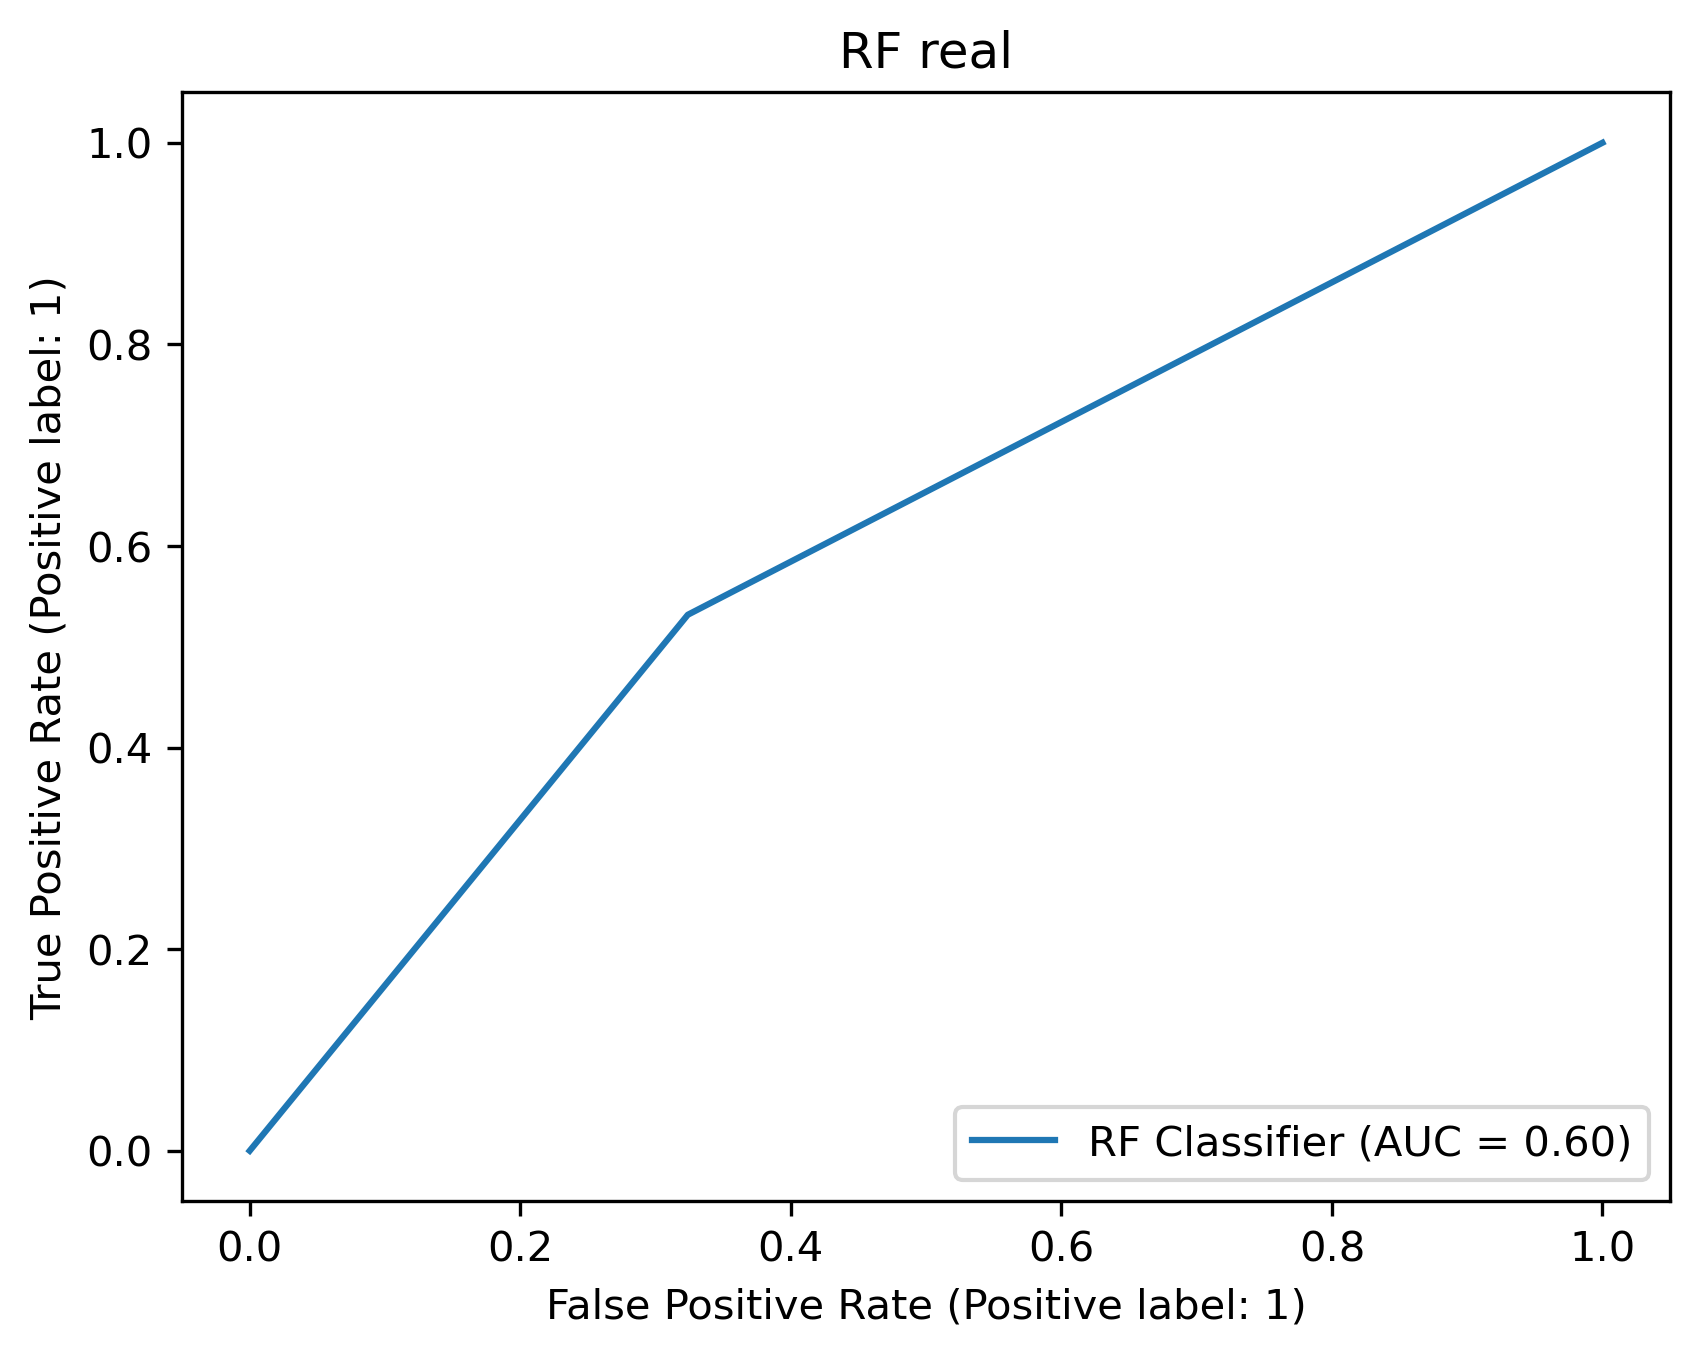

In [31]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="RF Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('RF real')
plt.show()

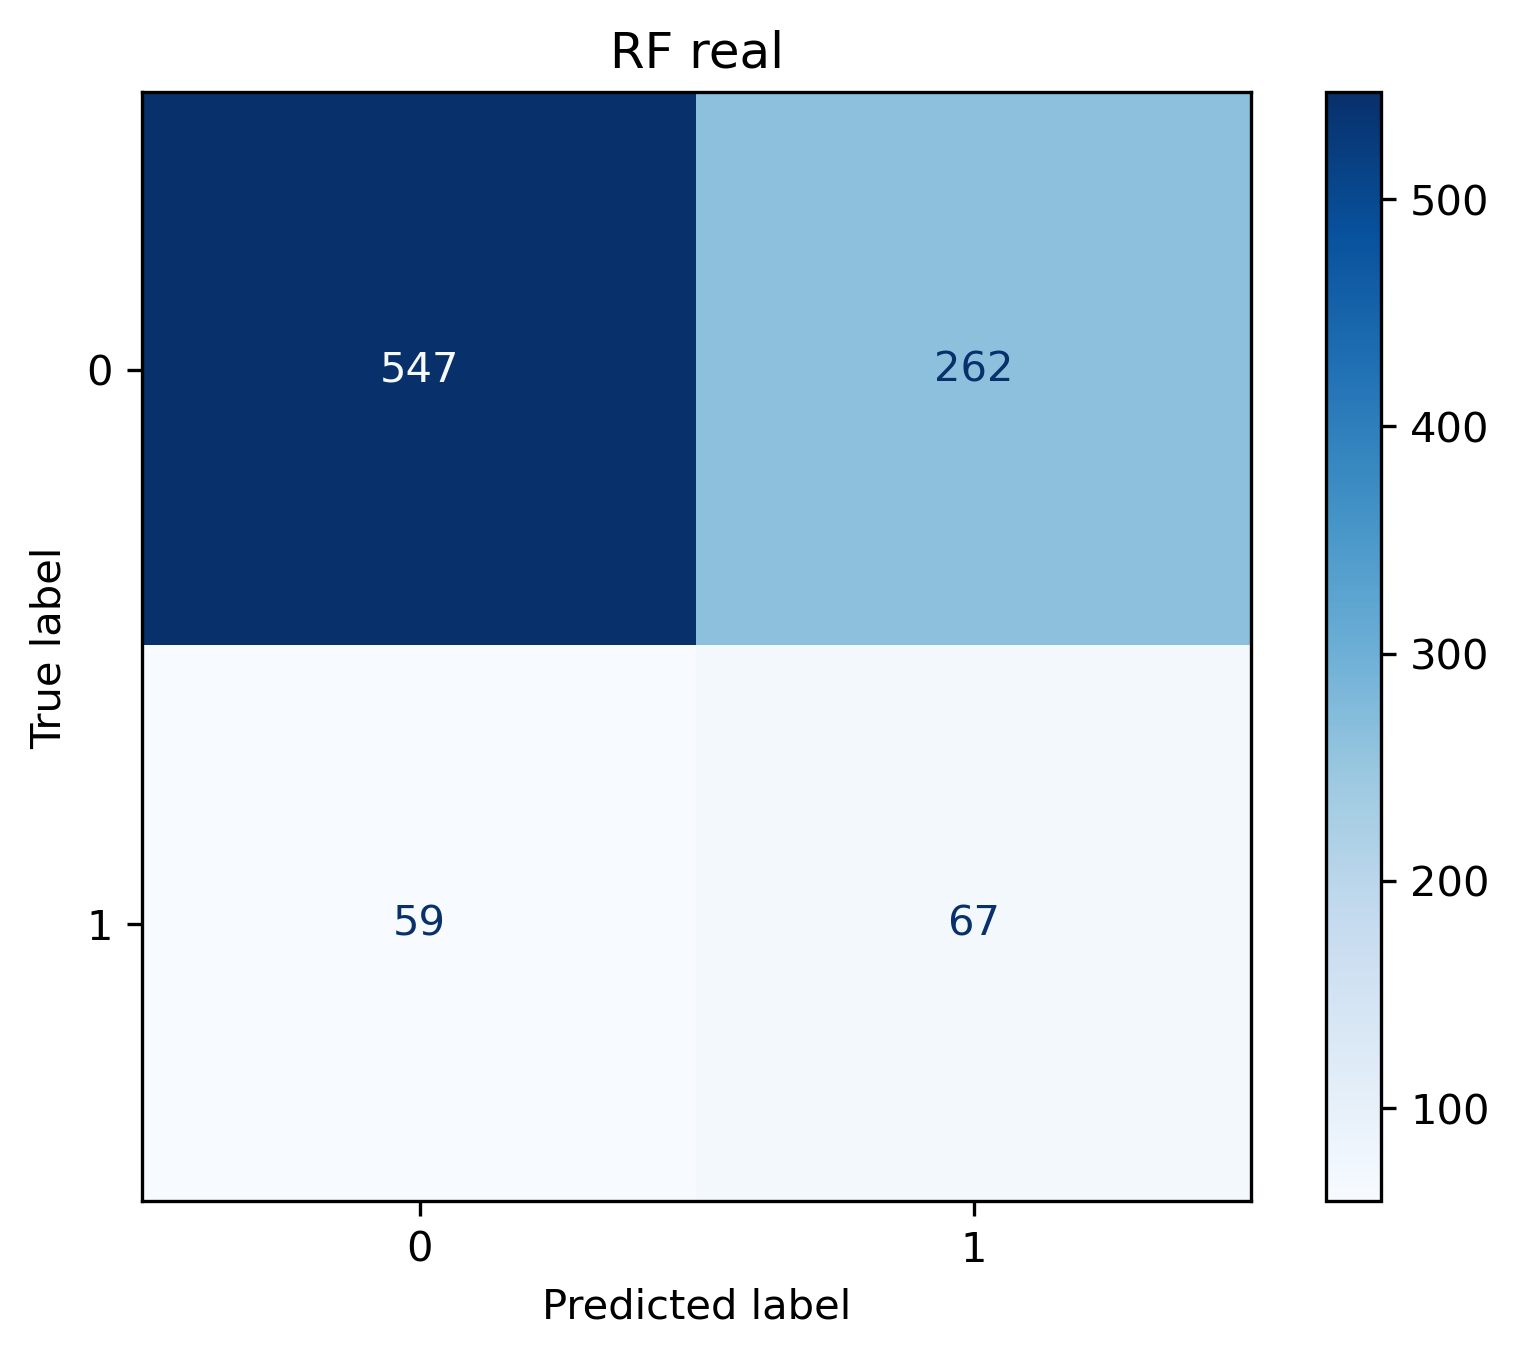

In [32]:



y_pred = rf_r.predict(X_test_r)
ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('RF real')
plt.show()

###  Train Synthetic, Test Real

In [33]:
y_pred = rf_s.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')


              precision    recall  f1-score   support

           0       0.92      0.49      0.64       809
           1       0.18      0.72      0.29       126

    accuracy                           0.52       935
   macro avg       0.55      0.61      0.46       935
weighted avg       0.82      0.52      0.59       935
 



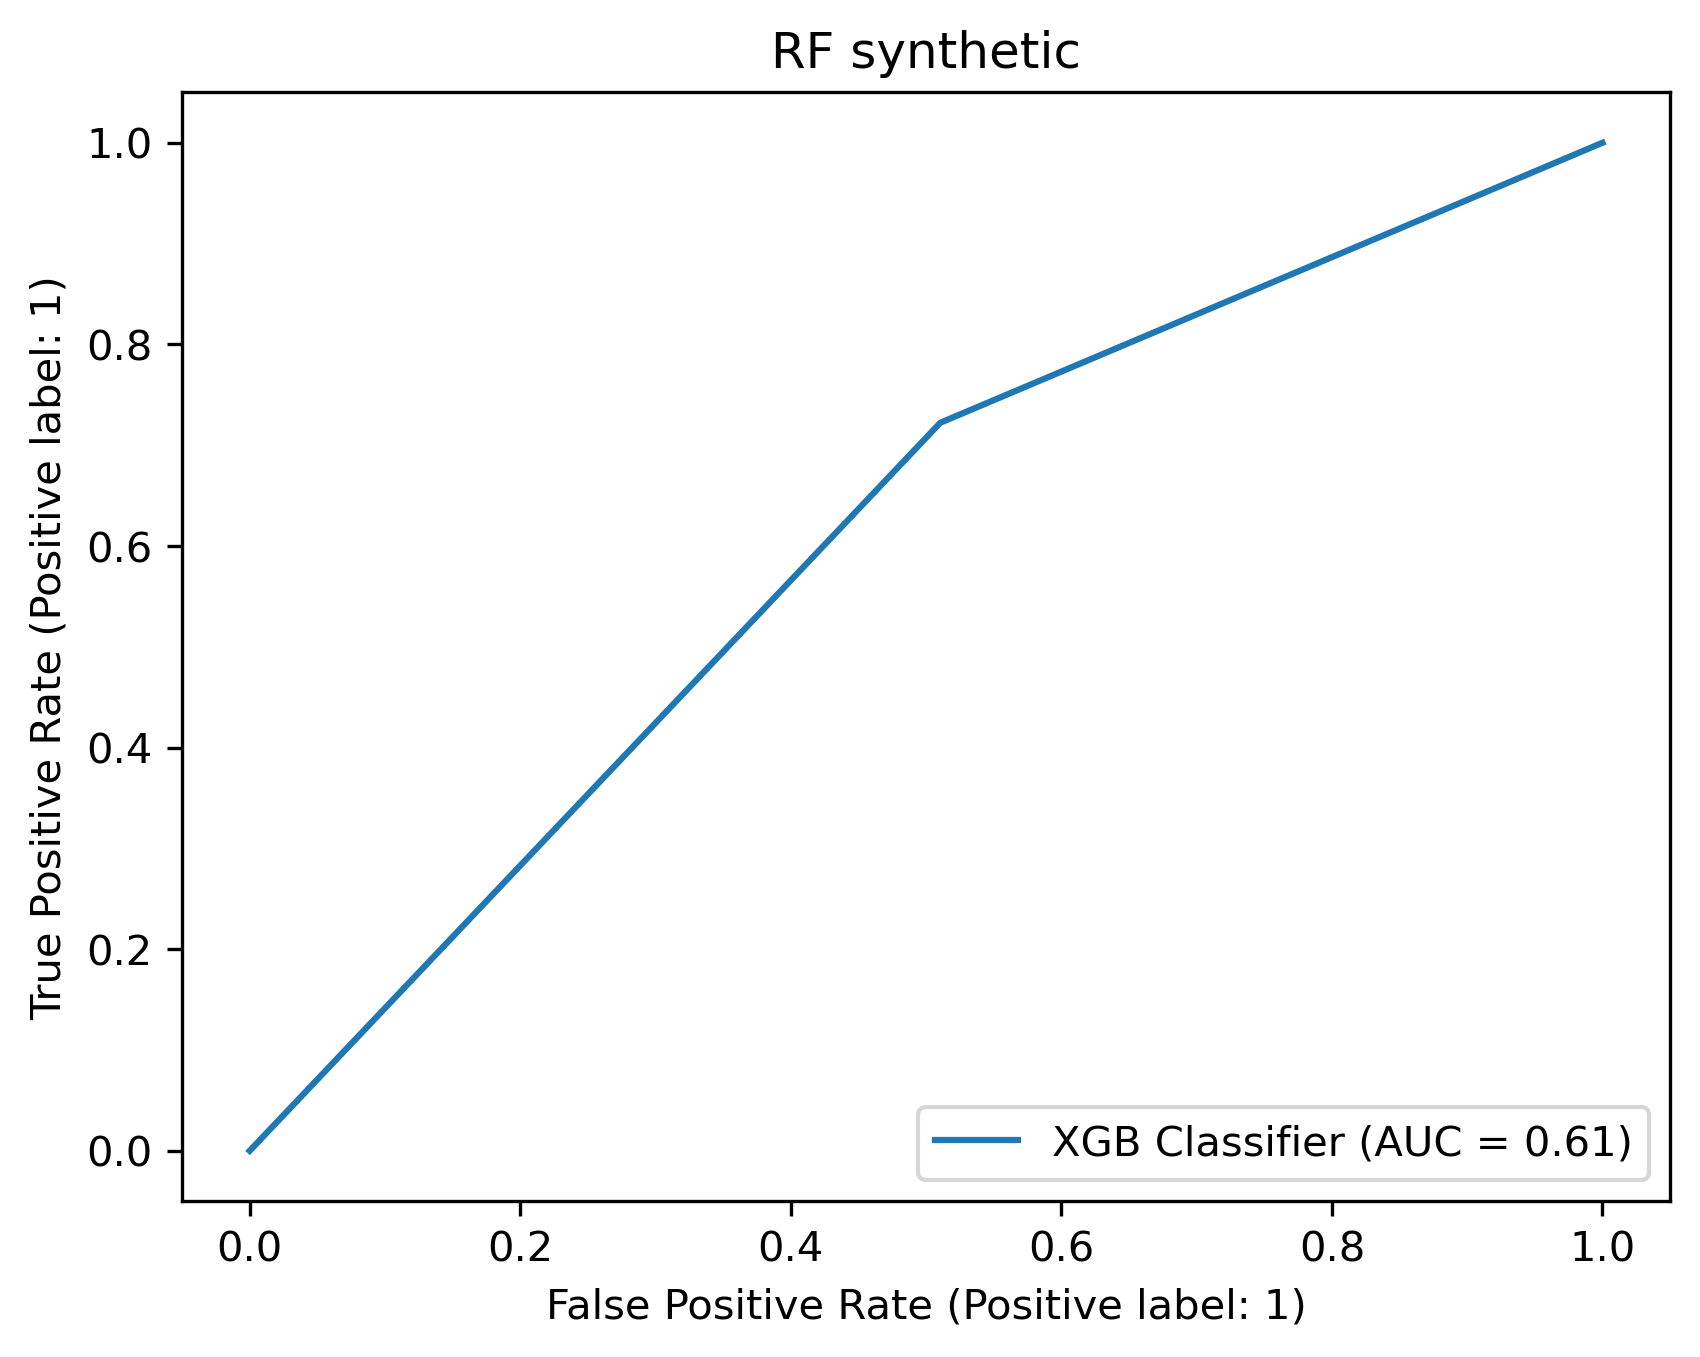

In [34]:
disp = RocCurveDisplay.from_predictions(y_test_r,  y_pred,name="XGB Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('RF synthetic')
plt.show()

In [35]:



y_pred_r = rf_r.predict(X_test_r)

y_pred_s = rf_s.predict(X_test_r)


<Figure size 1920x1440 with 0 Axes>

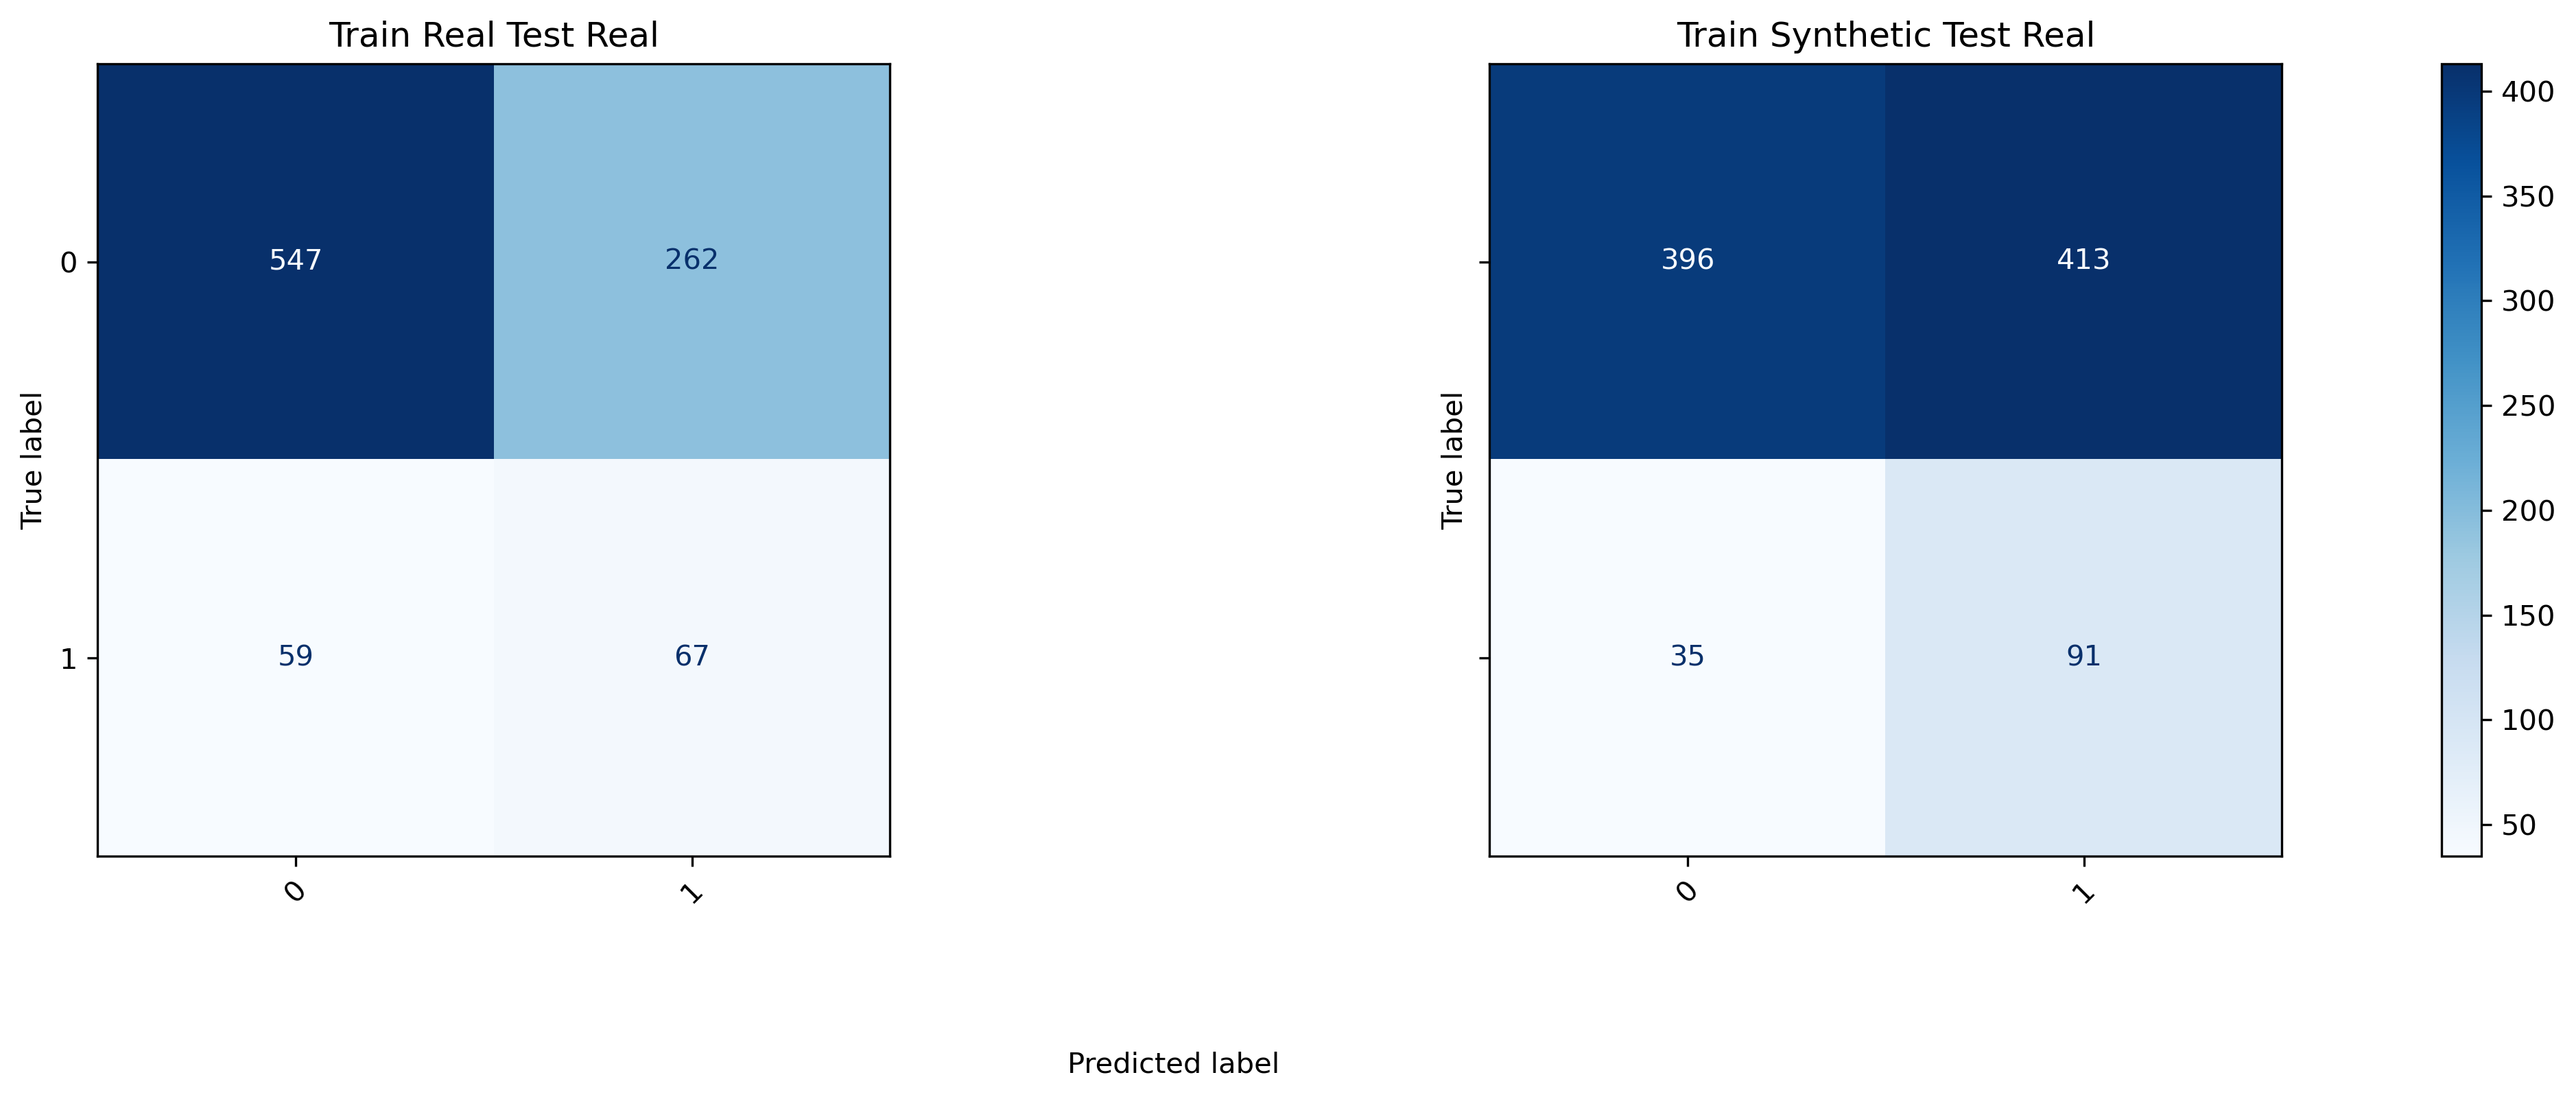

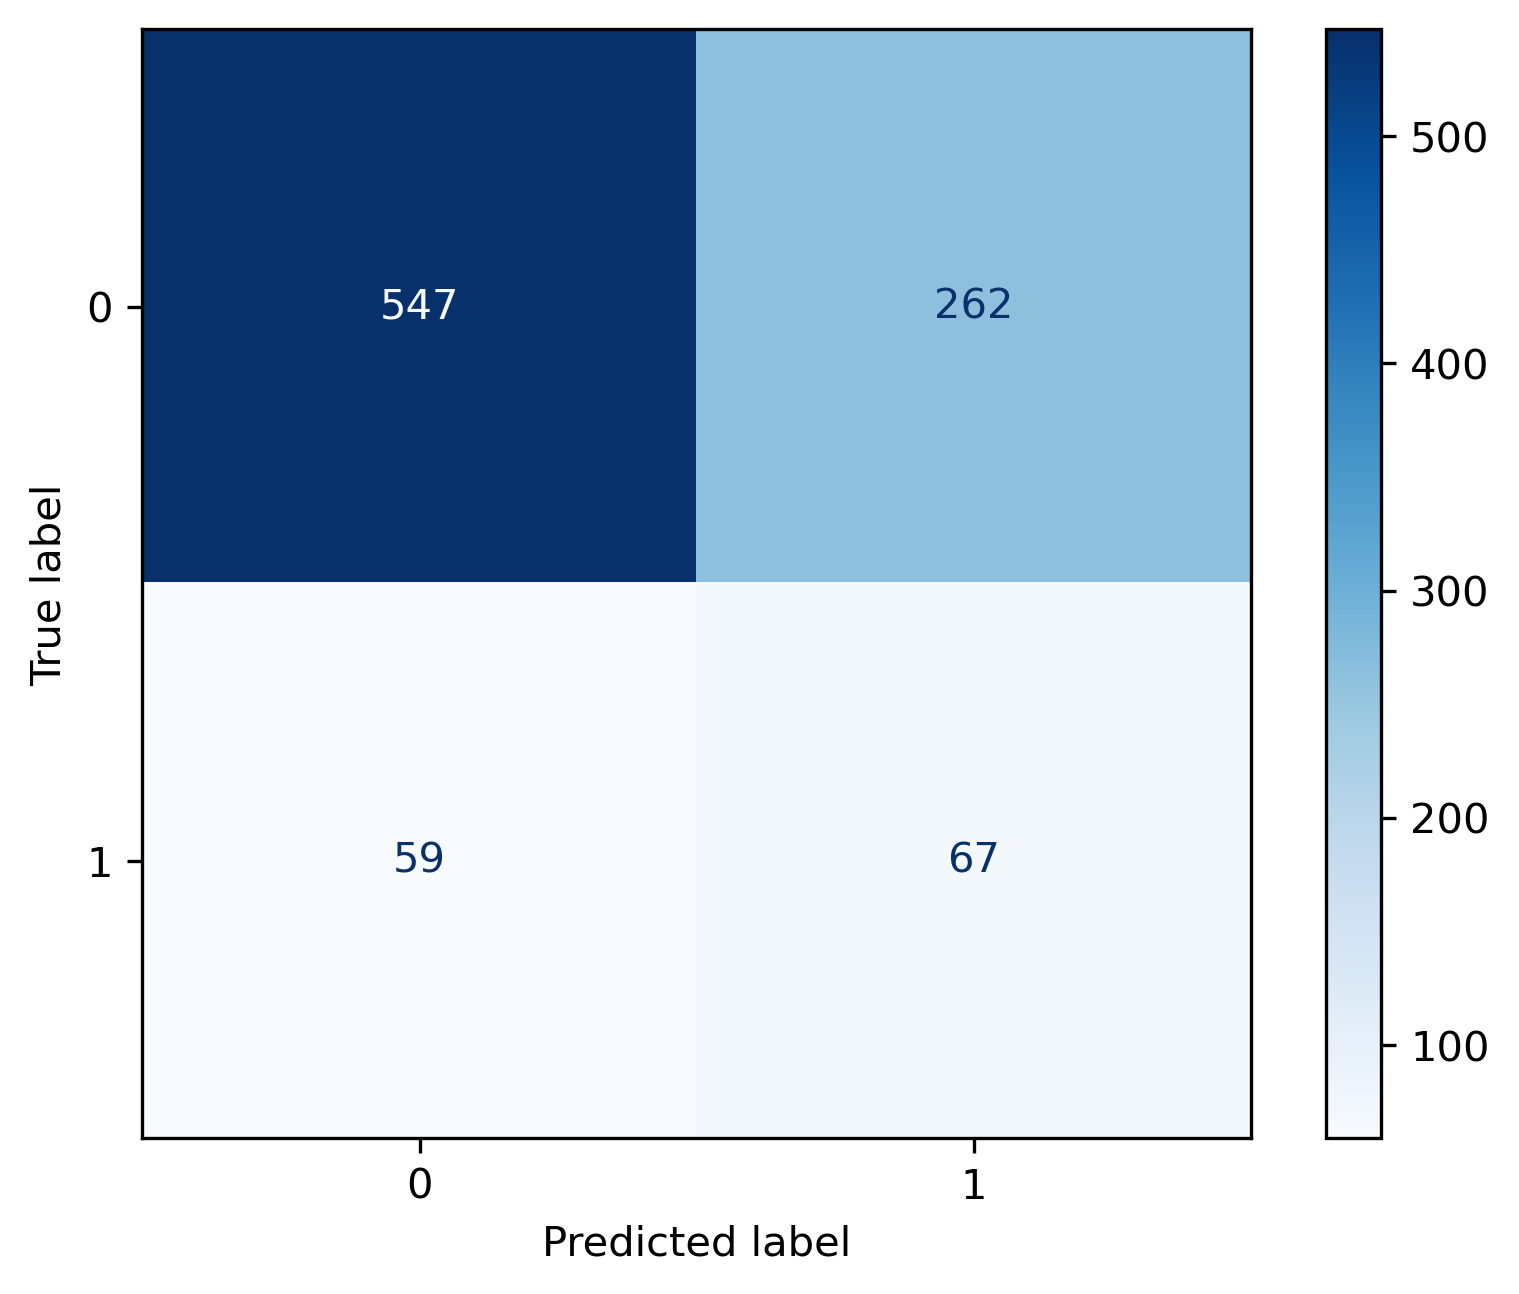

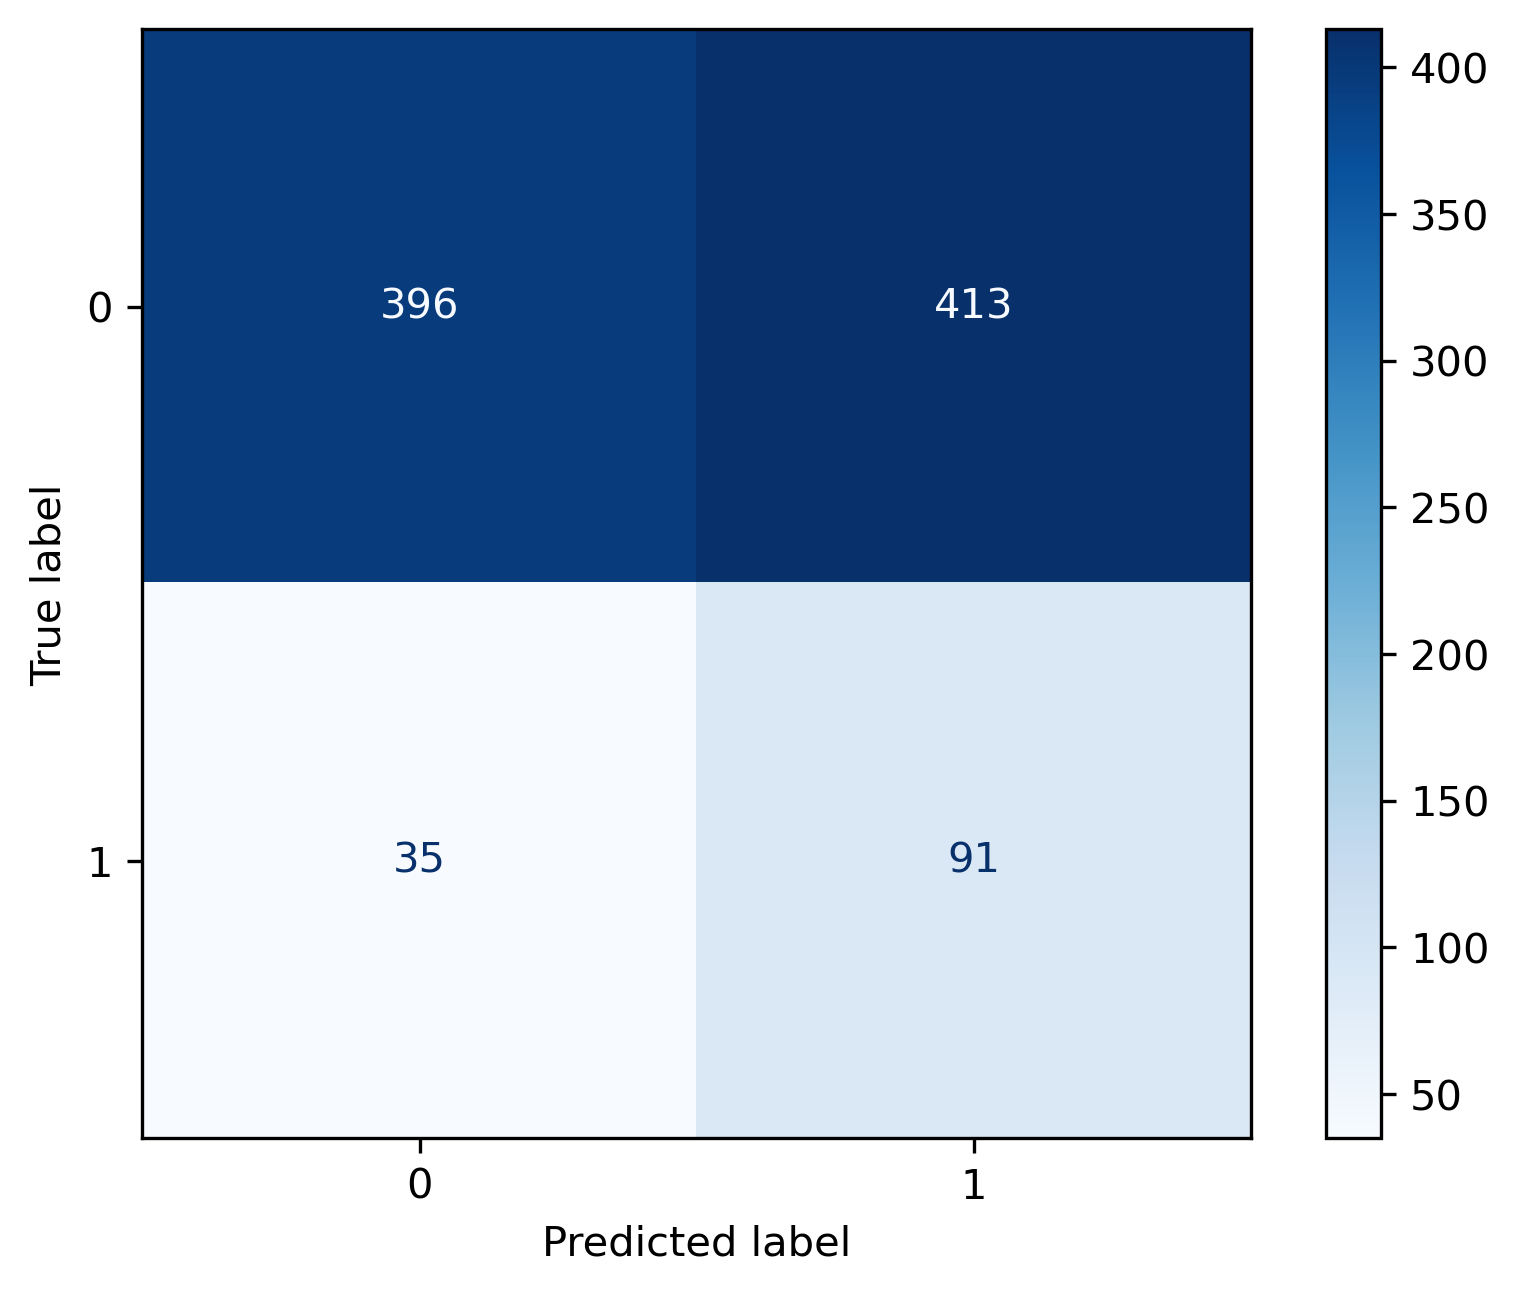

In [37]:

plt.figure()

f, axes = plt.subplots(1, 2, figsize=(20, 5), sharey='row')
disp = ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred_r,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
disp.plot(ax=axes[0], xticks_rotation=45,cmap=plt.cm.Blues,)
disp.ax_.set_title('Train Real Test Real')
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')


disp = ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred_s,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
disp.plot(ax=axes[1], xticks_rotation=45,cmap=plt.cm.Blues)
disp.ax_.set_title('Train Synthetic Test Real')
disp.im_.colorbar.remove()
disp.ax_.set_xlabel('')




f.text(0.45, -0.1, 'Predicted label', ha='left')
#plt.subplots_adjust(wspace=0.40, hspace=0.1)


f.colorbar(disp.im_, ax=axes)
plt.show()


### Logistic regression 

In [55]:
import scipy.stats as stats

In [56]:
from sklearn.utils import class_weight


classes_weights_r = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=y_train_r
)

classes_weights_s = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=y_train_s
)

In [59]:
model = LogisticRegression(max_iter=200, random_state=random_state)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000] ,
              'class_weight': ['balanced']
              
              }
        


model_dict_r = model_train(model,X_train_r, X_test_r, y_train_r, y_test_r,param_grid)
lr_r = model_dict_r['clf']

params_r = lr_r.best_params_
lr_r = LogisticRegression(random_state=random_state,**params_r)

lr_r.fit(X_train_r, y_train_r)







LogisticRegression(C=0.1, class_weight='balanced', random_state=99999)

In [60]:

model_dict_s = model_train(model,X_train_s, X_test_s, y_train_s, y_test_s,param_grid)
lr_s = model_dict_s['clf']

params_s = lr_s.best_params_
lr_s = LogisticRegression(random_state=random_state,**params_s)

lr_s.fit(X_train_s, y_train_s)

LogisticRegression(C=10, class_weight='balanced', random_state=99999)

###  Train Real, Test Real

In [61]:
y_pred = lr_r.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')

              precision    recall  f1-score   support

           0       0.92      0.60      0.73       809
           1       0.21      0.67      0.32       126

    accuracy                           0.61       935
   macro avg       0.56      0.63      0.52       935
weighted avg       0.82      0.61      0.67       935
 



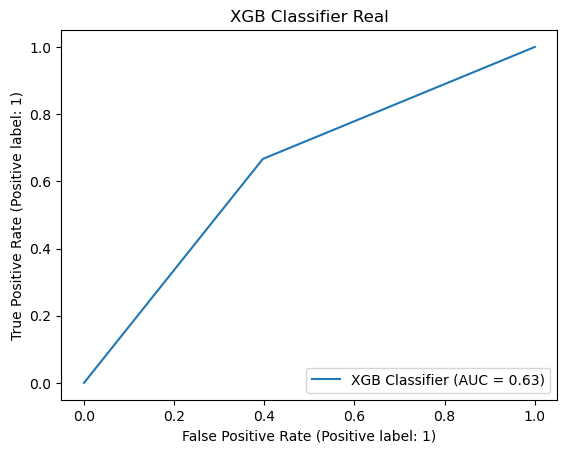

In [62]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="XGB Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier Real')
plt.show()

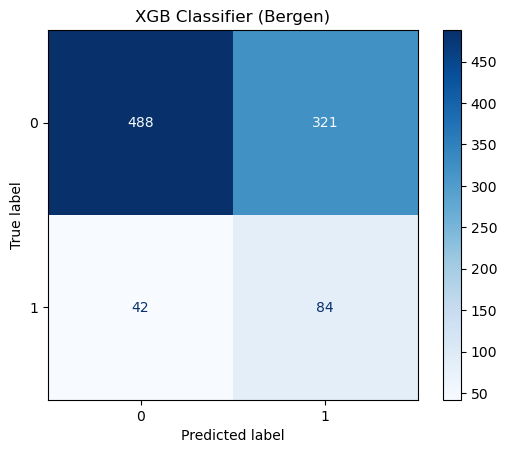

In [63]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,PrecisionRecallDisplay



ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier (Bergen)')
plt.show()

###  Train Synthetic, Test Real

In [64]:
y_pred = lr_s.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')



              precision    recall  f1-score   support

           0       0.91      0.56      0.69       809
           1       0.19      0.66      0.29       126

    accuracy                           0.57       935
   macro avg       0.55      0.61      0.49       935
weighted avg       0.82      0.57      0.64       935
 



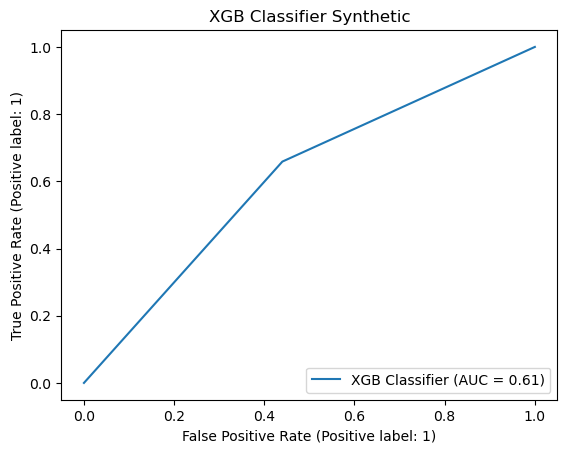

In [65]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="XGB Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier Synthetic')
plt.show()

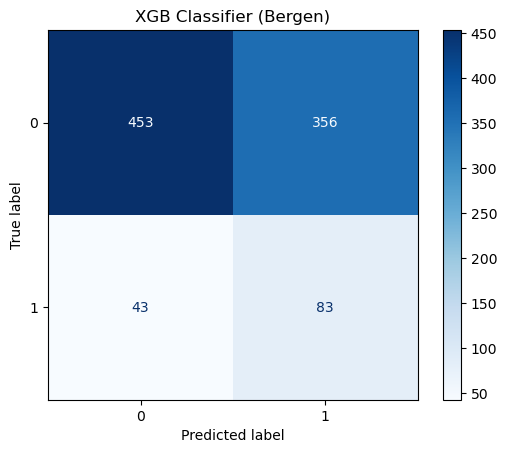

In [66]:


ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier (Bergen)')
plt.show()

### Desision Tree  regression 

In [67]:
from sklearn.tree import DecisionTreeClassifier

In [88]:

model = DecisionTreeClassifier(random_state=314)

param_grid=parameters={'criterion':['gini','entropy'],

            "max_depth" : [1,3,5,7,9,11,12],
          # "min_samples_split":[1,2,3,4,5,6,7,8,9,10],
           "min_samples_leaf":[1,2,3,4,5],
          # "min_weight_fraction_leaf":[0.1,0.2,0.3,0.4,0.5],
           "max_features":["log2","sqrt",None],
           'class_weight':["balanced"]
}

model_dict_r = model_train(model,X_train_r, X_test_r, y_train_r, y_test_r,param_grid)
dt_r = model_dict_r['clf']

#params_r = model_r.best_params_
#dt_r = DecisionTreeClassifier( random_state=314,**params_r)

dt_r.fit(X_train_r, y_train_r)











/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 813, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 471, in _score
    return self._sign * self._score_func(y, y_pred, **scoring_kwargs)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 211, in wrapper
    return func(*args, **kwargs)
  File "/opt/miniconda3/en

HalvingGridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=314),
                    n_jobs=-1,
                    param_grid={'class_weight': ['balanced'],
                                'criterion': ['gini', 'entropy'],
                                'max_depth': [1, 3, 5, 7, 9, 11, 12],
                                'max_features': ['log2', 'sqrt', None],
                                'min_samples_leaf': [1, 2, 3, 4, 5]},
                    scoring='roc_auc')

In [89]:


model_dict_s = model_train(model,X_train_s, X_test_s, y_train_s, y_test_s,param_grid)
dt_s = model_dict_s['clf']

#params_s = model_s.best_params_
#dt_s = DecisionTreeClassifier( random_state=314,**params_s)

dt_s.fit(X_train_s, y_train_s)

HalvingGridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=314),
                    n_jobs=-1,
                    param_grid={'class_weight': ['balanced'],
                                'criterion': ['gini', 'entropy'],
                                'max_depth': [1, 3, 5, 7, 9, 11, 12],
                                'max_features': ['log2', 'sqrt', None],
                                'min_samples_leaf': [1, 2, 3, 4, 5]},
                    scoring='roc_auc')

###  Train Real, Test Real

In [90]:
y_pred = dt_r.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')


              precision    recall  f1-score   support

           0       0.90      0.65      0.76       809
           1       0.20      0.55      0.29       126

    accuracy                           0.64       935
   macro avg       0.55      0.60      0.52       935
weighted avg       0.81      0.64      0.69       935
 



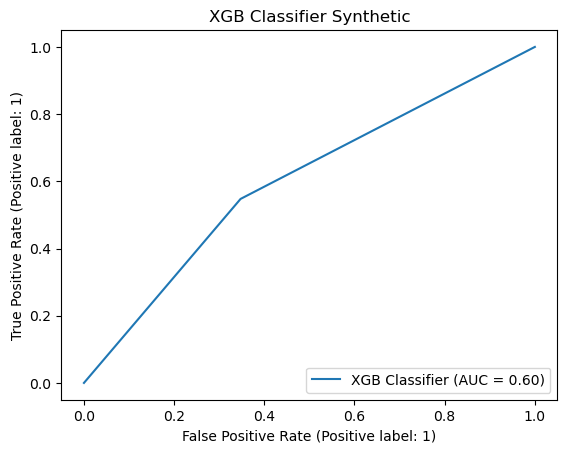

In [91]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="XGB Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier Synthetic')
plt.show()

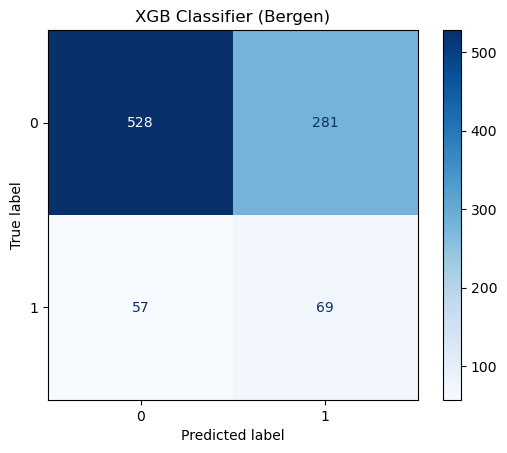

In [92]:


y_pred = dt_r.predict(X_test_r)
ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier (Bergen)')
plt.show()

###  Train Synthetic, Test Real

In [93]:
y_pred = dt_s.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')


              precision    recall  f1-score   support

           0       0.92      0.50      0.65       809
           1       0.18      0.71      0.29       126

    accuracy                           0.53       935
   macro avg       0.55      0.60      0.47       935
weighted avg       0.82      0.53      0.60       935
 



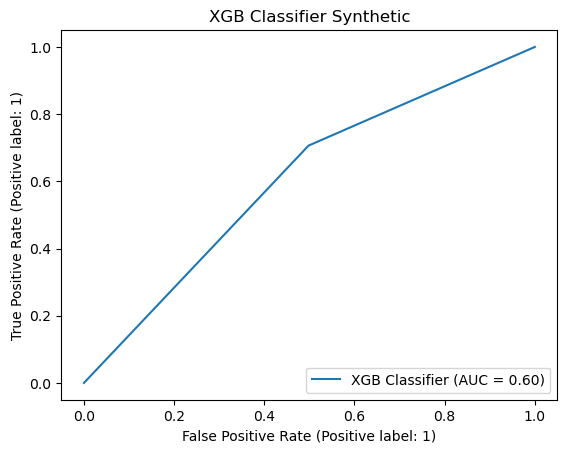

In [94]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="XGB Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier Synthetic')
plt.show()

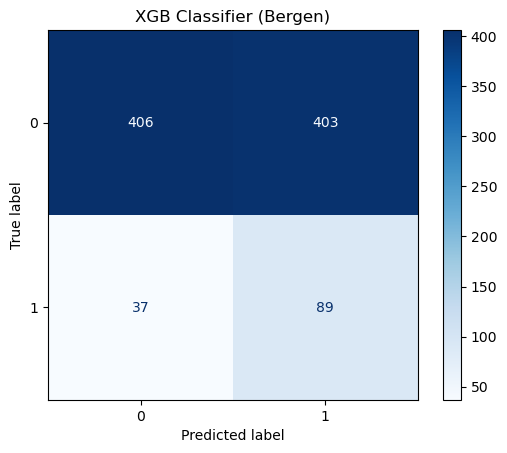

In [95]:


y_pred = dt_s.predict(X_test_r)
ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('XGB Classifier (Bergen)')
plt.show()

## lightgbm

In [69]:
import lightgbm as lgb


In [70]:
model= lgb.LGBMClassifier( random_state=random_state,verbose=-1)

param_grid={'is_unbalance':['True'],
          
       'learning_rate' : [0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.1, 0.2, 0.3, 0.4],
       "num_leaves": [31, 63, 127],
"max_depth": [-1, 3, 5],
"subsample": [0.8, 1.0],
"colsample_bytree": [0.8, 1.0],

    
    
    
}

model_dict_r = model_train(model,X_train_r, X_test_r, y_train_r, y_test_r,param_grid)
lgb_r = model_dict_r['clf']

params_r = lgb_r.best_params_
lgb_r = lgb.LGBMClassifier( random_state=314,**params_r)

lgb_r.fit(X_train_r, y_train_r)




/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 813, in _score
    scores = scorer(estimator, X_test, y_test)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 266, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 471, in _score
    return self._sign * self._score_func(y, y_pred, **scoring_kwargs)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/_param_validation.py", line 211, in wrapper
    return func(*args, **kwargs)
  File "/opt/miniconda3/en

[LightGBM] [Info] Number of positive: 294, number of negative: 1886
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33
[LightGBM] [Info] Number of data points in the train set: 2180, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134862 -> initscore=-1.858634
[LightGBM] [Info] Start training from score -1.858634
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LGBMClassifier(colsample_bytree=0.8, is_unbalance='True', learning_rate=0.02,
               max_depth=5, num_leaves=127, random_state=314, subsample=0.8)

In [71]:



model_dict_s = model_train(model,X_train_s, X_test_s, y_train_s, y_test_s,param_grid)
lgb_s = model_dict_s['clf']

params_s = lgb_s.best_params_
lgb_s = lgb.LGBMClassifier( random_state=314,**params_s)

lgb_s.fit(X_train_s, y_train_s)

[LightGBM] [Info] Number of positive: 2982, number of negative: 7716
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 36
[LightGBM] [Info] Number of data points in the train set: 10698, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.278744 -> initscore=-0.950702
[LightGBM] [Info] Start training from score -0.950702
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

LGBMClassifier(colsample_bytree=0.8, is_unbalance='True', learning_rate=0.03,
               max_depth=3, num_leaves=127, random_state=314)

###  Train Real, Test Real

In [72]:
y_pred = lgb_r.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')


              precision    recall  f1-score   support

           0       0.90      0.69      0.78       809
           1       0.21      0.51      0.29       126

    accuracy                           0.67       935
   macro avg       0.55      0.60      0.54       935
weighted avg       0.81      0.67      0.72       935
 



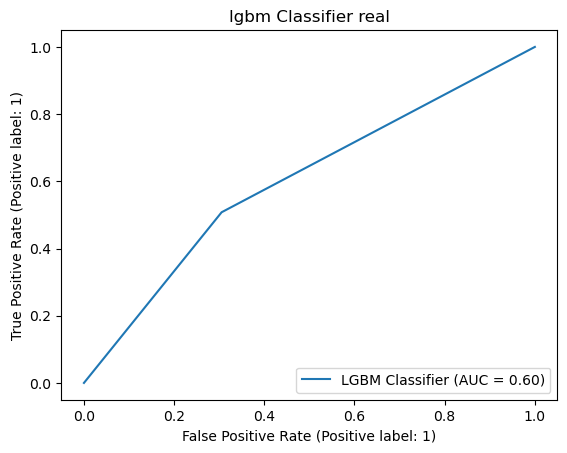

In [73]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="LGBM Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('lgbm Classifier real')
plt.show()

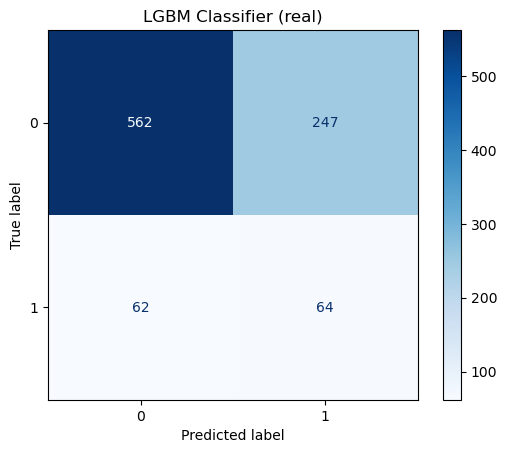

In [74]:


y_pred = lgb_r.predict_proba(X_test_r)
ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred[:,1]>=.5,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('LGBM Classifier (real)')
plt.show()

###  Train Synthetic, Test Real

In [75]:
y_pred = lgb_s.predict(X_test_r)
print(classification_report(y_test_r, y_pred),'\n')

              precision    recall  f1-score   support

           0       0.90      0.56      0.69       809
           1       0.18      0.62      0.28       126

    accuracy                           0.57       935
   macro avg       0.54      0.59      0.49       935
weighted avg       0.81      0.57      0.64       935
 



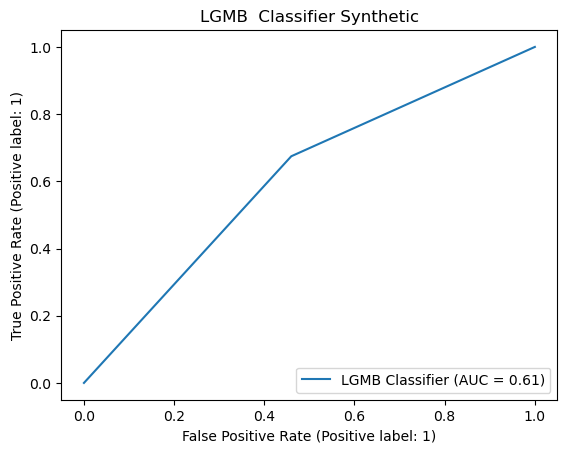

In [148]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="LGMB Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('LGMB  Classifier Synthetic')
plt.show()

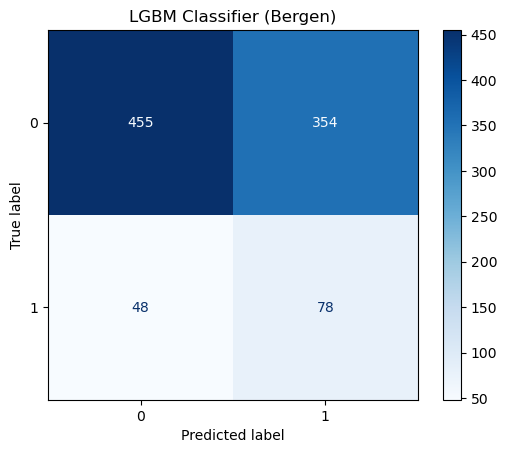

In [149]:


y_pred = lgb_s.predict(X_test_r)
ConfusionMatrixDisplay.from_predictions(y_test_r,
                                             y_pred,

                                             #display_labels=target_names,
                                             cmap=plt.cm.Blues,
                                             normalize=None
                                            )
    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('LGBM Classifier (Bergen)')
plt.show()

## Voting Classifier

In [156]:
vote_r = VotingClassifier (estimators = [('lgb_r', lgb_r), ('lr_r', lr_r), ('rf_r', rf_r),('dt', dt_r)], 
                         voting='soft', n_jobs=-1)
vote_r.fit(X_train_r,y_train_r)


/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 459, in _score
    y_pred = method_caller(clf, "decision_function", X, pos_label=pos_label)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/_response.py", line 73, in _get_response_values
    prediction_method = _check_response_method(estimator, response_method)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/validation.py", line 1940, in _check_response_method
    raise AttributeError(
AttributeError: DecisionTreeClas

[LightGBM] [Info] Number of positive: 294, number of negative: 1886
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 33
[LightGBM] [Info] Number of data points in the train set: 2180, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134862 -> initscore=-1.858634
[LightGBM] [Info] Start training from score -1.858634
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 459, in _score
    y_pred = method_caller(clf, "decision_function", X, pos_label=pos_label)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/_response.py", line 73, in _get_response_values
    prediction_method = _check_response_method(estimator, response_method)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/validation.py", line 1940, in _check_response_method
    raise AttributeError(
AttributeError: DecisionTreeClas

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 459, in _score
    y_pred = method_caller(clf, "decision_function", X, pos_label=pos_label)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/_response.py", line 73, in _get_response_values
    prediction_method = _check_response_method(estimator, response_method)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/validation.py", line 1940, in _check_response_method
    raise AttributeError(
AttributeError: DecisionTreeClas

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:824: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 459, in _score
    y_pred = method_caller(clf, "decision_function", X, pos_label=pos_label)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/_response.py", line 73, in _get_response_values
    prediction_method = _check_response_method(estimator, response_method)
  File "/opt/miniconda3/envs/sdv_env/lib/python3.10/site-packages/sklearn/utils/validation.py", line 1940, in _check_response_method
    raise AttributeError(
AttributeError: DecisionTreeClas

VotingClassifier(estimators=[('lgb_r',
                              LGBMClassifier(colsample_bytree=0.8,
                                             is_unbalance='True',
                                             learning_rate=0.02, max_depth=5,
                                             num_leaves=127, random_state=314,
                                             subsample=0.8)),
                             ('lr_r',
                              LogisticRegression(C=0.1, class_weight='balanced',
                                                 random_state=99999)),
                             ('rf_r',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=3,
                                                     max_features=1,
                                                     random_state=99999)),
                             ('dt',
                              HalvingGridSearchCV(cv=3,
                                                  estimator=DecisionTreeClassifier(random_state=314),
                                                  n_jobs=-1,
                                                  param_grid={'class_weight': ['balanced'],
                                                              'criterion': ['gini',
                                                                            'entropy'],
                                                              'max_depth': [1,
                                                                            3,
                                                                            5,
                                                                            7,
                                                                            9,
                                                                            11,
                                                                            12],
                                                              'max_features': ['log2',
                                                                               'sqrt',
                                                                               None],
                                                              'min_samples_leaf': [1,
                                                                                   2,
                                                                                   3,
                                                                                   4,
                                                                                   5]},
                                                  scoring='roc_auc'))],
                 n_jobs=-1, voting='soft')

In [157]:
y_pred = vote_r.predict(X_test_r)
print(confusion_matrix(y_test_r, y_pred))
print(classification_report(y_test_r, y_pred))

[[502 307]
 [ 46  80]]
              precision    recall  f1-score   support

           0       0.92      0.62      0.74       809
           1       0.21      0.63      0.31       126

    accuracy                           0.62       935
   macro avg       0.56      0.63      0.53       935
weighted avg       0.82      0.62      0.68       935



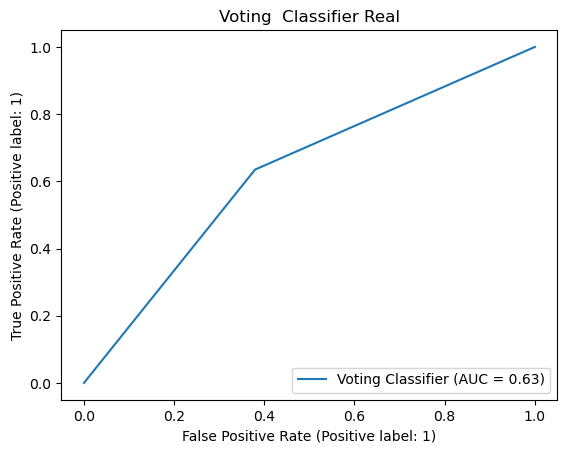

In [158]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="Voting Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('Voting  Classifier Real')
plt.show()

In [164]:
vote_s = VotingClassifier (estimators = [('lgb', lgb_s), ('lr', lr_s), ('rf', rf_s),('dt', dt_s)], 
                         voting='soft', n_jobs=-1)
vote_s.fit(X_train_s,y_train_s)


[LightGBM] [Info] Number of positive: 2982, number of negative: 7716
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000519 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 36
[LightGBM] [Info] Number of data points in the train set: 10698, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.278744 -> initscore=-0.950702
[LightGBM] [Info] Start training from score -0.950702
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

VotingClassifier(estimators=[('lgb',
                              LGBMClassifier(colsample_bytree=0.8,
                                             is_unbalance='True',
                                             learning_rate=0.03, max_depth=3,
                                             num_leaves=127,
                                             random_state=314)),
                             ('lr',
                              LogisticRegression(C=10, class_weight='balanced',
                                                 random_state=99999)),
                             ('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=3,
                                                     max_features=1,
                                                     min_samples_leaf=2,
                                                     min_samples_split=10,
                                                     n_estimators=200,
                                                     random_state=99999)),
                             ('dt',
                              HalvingGridSearchCV(cv=3,
                                                  estimator=DecisionTreeClassifier(random_state=314),
                                                  n_jobs=-1,
                                                  param_grid={'class_weight': ['balanced'],
                                                              'criterion': ['gini',
                                                                            'entropy'],
                                                              'max_depth': [1,
                                                                            3,
                                                                            5,
                                                                            7,
                                                                            9,
                                                                            11,
                                                                            12],
                                                              'max_features': ['log2',
                                                                               'sqrt',
                                                                               None],
                                                              'min_samples_leaf': [1,
                                                                                   2,
                                                                                   3,
                                                                                   4,
                                                                                   5]},
                                                  scoring='roc_auc'))],
                 n_jobs=-1, voting='soft')

In [165]:
y_pred = vote_s.predict(X_test_r)
print(confusion_matrix(y_test_r, y_pred))
print(classification_report(y_test_r, y_pred))

[[420 389]
 [ 38  88]]
              precision    recall  f1-score   support

           0       0.92      0.52      0.66       809
           1       0.18      0.70      0.29       126

    accuracy                           0.54       935
   macro avg       0.55      0.61      0.48       935
weighted avg       0.82      0.54      0.61       935



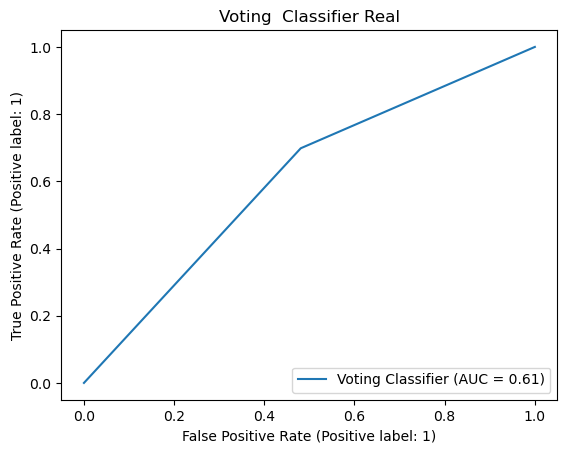

In [166]:
disp = RocCurveDisplay.from_predictions(y_test_r, y_pred,name="Voting Classifier")    #disp = PrecisionRecallDisplay.from_predictions(y_test, predictions_train[i],name=i)

#plt.title(i)
    #print(cm)
    #print(classification_report(y_test, predictions_test[i]),'\n')
plt.title('Voting  Classifier Real')
plt.show()

## Explanatory with SAHP

In [38]:
import shap

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [39]:

explainer_r = shap.TreeExplainer(rf_r)
shap_values_r = explainer_r(X_test_r)

explainer_s = shap.TreeExplainer(rf_s)
shap_values_s = explainer_s(X_test_r)

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


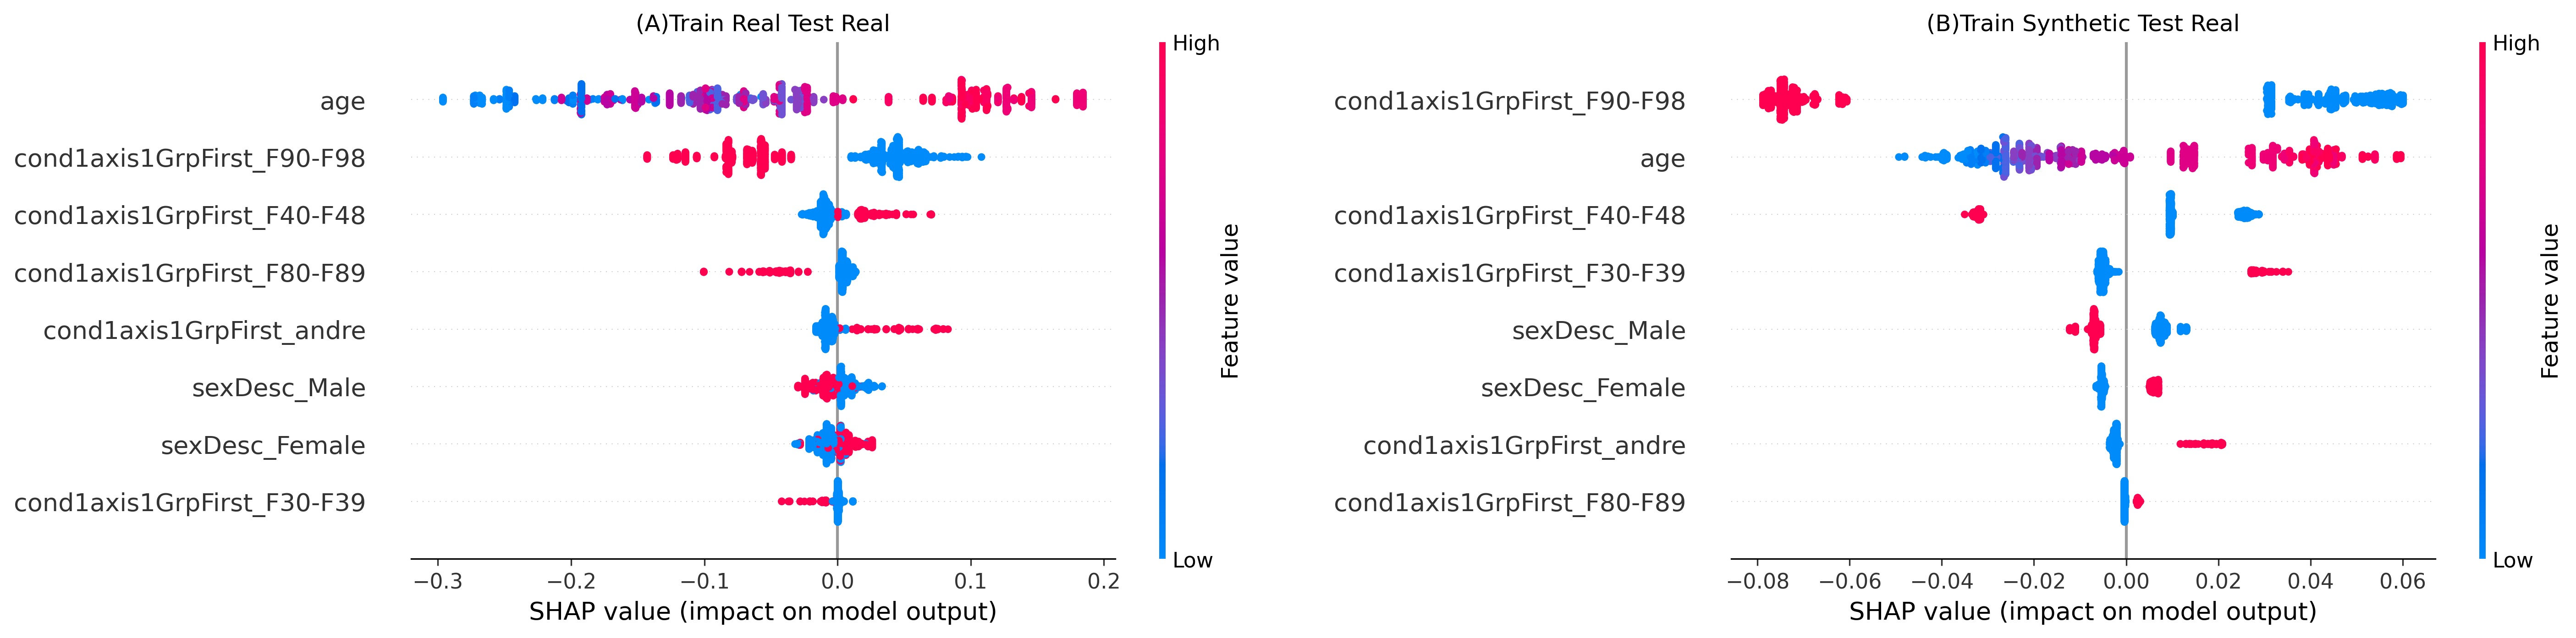

In [40]:


plt.figure()
plt.subplot(1,2,1)
shap.plots.beeswarm(shap_values_r[:,:,1], max_display=20,show=False)
plt.title("(A)Train Real Test Real")
plt.subplots_adjust(wspace = 0.5)
plt.subplot(1,2,2)

shap.plots.beeswarm(shap_values_s[:,:,1], max_display=20,show=False)
plt.title("(B)Train Synthetic Test Real")
plt.subplots_adjust(wspace = 0.5)
# Optional for adjusting the margins:
plt.subplots_adjust(
    left=1,
    bottom=0.1, 
    right=3, 
    top=0.9
)

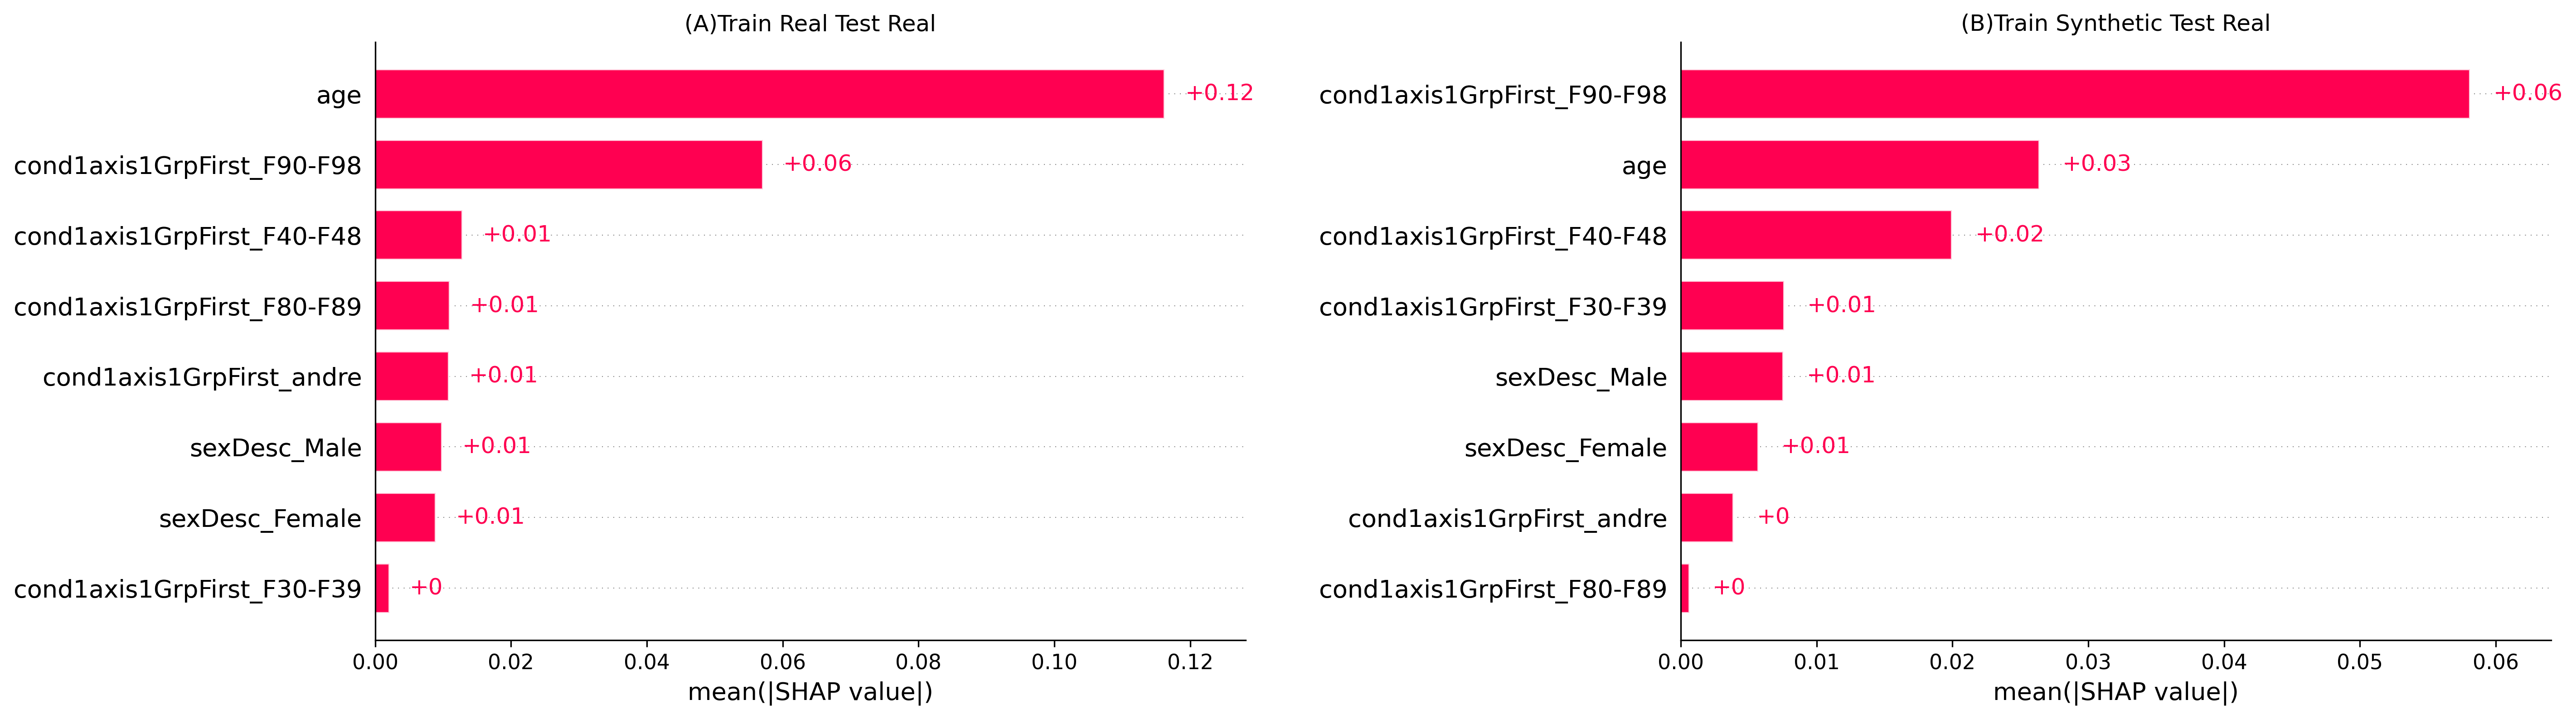

In [41]:

plt.figure()
plt.subplot(1,2,1)
shap.plots.bar(shap_values_r[:,:,1], show=False)
plt.title("(A)Train Real Test Real")
plt.subplots_adjust(wspace = 0.5)
plt.subplot(1,2,2)

shap.plots.bar(shap_values_s[:,:,1], show=False)
plt.title("(B)Train Synthetic Test Real")
plt.subplots_adjust(wspace = 0.5)
# Optional for adjusting the margins:
plt.subplots_adjust(
    left=1,
    bottom=0.1, 
    right=3, 
    top=0.9
)
